# Lab 5. N-Gram Language Models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-05-ngram-language-models.ipynb)

This lab accompanies Chapter 5 of **Mathematical Natural Language Processing**.

In the previous lab, we studied probability distributions for language. In this lab, we turn those ideas into a simple language model:

$$
\text{training text} \longrightarrow \text{counts} \longrightarrow \text{conditional probabilities} \longrightarrow \text{prediction and generation}.
$$

The main model is an $n$-gram language model. It predicts the next token from only the previous $n-1$ tokens. Although this is much simpler than a transformer, the same central question appears:

$$
p(w_t \mid \text{context}).
$$

## How to use this lab

1. Read the mathematical explanation before running each code block.
2. Run all cells in order.
3. Inspect the tables and generated examples.
4. When you see **Try it yourself**, modify the code and rerun the cell.
5. Complete the exercises and mini-project at the end.

The lab uses only standard Python scientific tools: `numpy`, `pandas`, and `matplotlib`. Everything should run directly in Google Colab.

## Learning goals

After completing this lab, you should be able to:

- define unigrams, bigrams, trigrams, and general $n$-grams;
- explain the Markov approximation in an $n$-gram model;
- add start and end boundary tokens correctly;
- estimate conditional probabilities by maximum likelihood;
- explain and implement add-$\alpha$ smoothing;
- compute sentence log-probability, average negative log-likelihood, and perplexity;
- sample text from a fitted $n$-gram model;
- represent a bigram model as a row-stochastic transition matrix;
- compare unigram, bigram, and trigram models on the same test set;
- understand the bias-variance tradeoff caused by increasing $n$.

## 1. Mathematical background

Let

$$
V=\{v_1,v_2,\ldots,v_d\}
$$

be a finite vocabulary. A sentence is a token sequence

$$
w_{1:T}=(w_1,w_2,\ldots,w_T), \qquad w_t \in V.
$$

The exact chain rule says

$$
p(w_{1:T})=\prod_{t=1}^T p(w_t \mid w_1,\ldots,w_{t-1}).
$$

This formula is exact, but it is hard to estimate because the possible histories $w_1,\ldots,w_{t-1}$ are too numerous.

An $n$-gram model uses the Markov approximation

$$
p(w_t \mid w_1,\ldots,w_{t-1}) \approx p(w_t \mid w_{t-n+1},\ldots,w_{t-1}).
$$

For example:

- a unigram model ignores context;
- a bigram model uses one previous token;
- a trigram model uses two previous tokens.

If $h$ denotes the context and $v$ denotes the next token, the maximum likelihood estimator is

$$
\widehat p(v \mid h)=\frac{C(h,v)}{C(h)},
$$

where $C(h,v)$ counts how often $h$ is followed by $v$, and $C(h)=\sum_v C(h,v)$.

The zero-count problem is solved, in a basic way, by add-$\alpha$ smoothing:

$$
\widehat p_\alpha(v \mid h)=\frac{C(h,v)+\alpha}{C(h)+\alpha |V|}.
$$

Finally, for a test corpus with correct-token probabilities $p_1,\ldots,p_N$, the average negative log-likelihood is

$$
\operatorname{NLL}_{\text{avg}}=-\frac{1}{N}\sum_{i=1}^N \log p_i,
$$

and the perplexity is

$$
\operatorname{Perplexity}=\exp(\operatorname{NLL}_{\text{avg}}).
$$

## 2. Setup

We import tools for tokenization, counting, arrays, tables, and visualization.

In [1]:
import re
import math
from collections import Counter, defaultdict
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 60)

rng = np.random.default_rng(7243)

## 3. A small mathematical NLP corpus

We use a small corpus about mathematical NLP. The corpus is intentionally small so that we can inspect the model. In real language modeling, the corpus would be much larger, but the mathematical objects are the same.

We will split the corpus into a training set and a test set. The model learns counts from the training set, and perplexity is measured on the test set.

In [2]:
corpus = [
    "language models assign probabilities to token sequences",
    "probability helps language models represent uncertainty",
    "bigram models estimate the next token from the previous token",
    "trigram models use two previous tokens as context",
    "smoothing gives nonzero probability to unseen events",
    "perplexity measures average uncertainty in next token prediction",
    "a vocabulary maps text into a finite set of symbols",
    "a corpus provides counts for statistical language models",
    "the markov assumption keeps only a short context",
    "maximum likelihood estimates probabilities from observed counts",
    "neural language models also predict the next token",
    "transformers use attention to represent long context",
    "retrieval augmented generation combines search and language models",
    "classification models assign labels to documents",
    "embeddings represent words and documents as vectors",
    "entropy measures uncertainty in a probability distribution",
    "cross entropy measures surprise under a model distribution",
    "language modeling connects probability statistics and computation",
    "students can inspect n gram counts by hand",
    "small models reveal mathematical structure clearly",
]

train_corpus = corpus[:16]
test_corpus = corpus[16:]

print(f"Training sentences: {len(train_corpus)}")
print(f"Test sentences: {len(test_corpus)}")
print("\nExample training sentence:")
print(train_corpus[0])

Training sentences: 16
Test sentences: 4

Example training sentence:
language models assign probabilities to token sequences


## 4. Tokenization and boundary tokens

We use a simple tokenizer that keeps lowercase alphabetic words. For an $n$-gram model, we also add boundary tokens.

For a bigram model, the sentence

```text
language models learn
```

becomes

```text
<s> language models learn </s>
```

For a trigram model, we use two start tokens:

```text
<s> <s> language models learn </s>
```

The start token `<s>` is used only as context. The end token `</s>` is a predicted token.

In [3]:
START = "<s>"
END = "</s>"
UNK = "<unk>"

def tokenize(text):
    """A small, transparent tokenizer for this lab."""
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())


def add_boundaries(tokens, n):
    """Add n-1 start tokens and one end token."""
    return [START] * (n - 1) + list(tokens) + [END]


def ngrams_from_tokens(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

example = "Bigram models estimate the next token."
for n in [1, 2, 3]:
    tokens = add_boundaries(tokenize(example), n)
    print(f"\nn = {n}")
    print("tokens:", tokens)
    print("n-grams:", ngrams_from_tokens(tokens, n))


n = 1
tokens: ['bigram', 'models', 'estimate', 'the', 'next', 'token', '</s>']
n-grams: [('bigram',), ('models',), ('estimate',), ('the',), ('next',), ('token',), ('</s>',)]

n = 2
tokens: ['<s>', 'bigram', 'models', 'estimate', 'the', 'next', 'token', '</s>']
n-grams: [('<s>', 'bigram'), ('bigram', 'models'), ('models', 'estimate'), ('estimate', 'the'), ('the', 'next'), ('next', 'token'), ('token', '</s>')]

n = 3
tokens: ['<s>', '<s>', 'bigram', 'models', 'estimate', 'the', 'next', 'token', '</s>']
n-grams: [('<s>', '<s>', 'bigram'), ('<s>', 'bigram', 'models'), ('bigram', 'models', 'estimate'), ('models', 'estimate', 'the'), ('estimate', 'the', 'next'), ('the', 'next', 'token'), ('next', 'token', '</s>')]


### Vocabulary and unknown tokens

A model cannot assign probabilities to arbitrary strings unless we define how to handle words outside the training vocabulary.

We include a special unknown token `<unk>`. During training, words that do not pass a frequency threshold can be mapped to `<unk>`. During testing, any word not in the training vocabulary is also mapped to `<unk>`.

In this lab, we use `min_count=1`, so every training word is kept. The `<unk>` token still matters for test words that never appeared during training.

In [4]:
def build_word_vocabulary(corpus, min_count=1):
    counts = Counter()
    for sentence in corpus:
        counts.update(tokenize(sentence))
    words = sorted([word for word, count in counts.items() if count >= min_count])
    return set(words), counts

known_words, training_word_counts = build_word_vocabulary(train_corpus, min_count=1)
print("Number of known training words:", len(known_words))
print("Most common training words:")
print(training_word_counts.most_common(12))

new_sentence = "foundation models predict coherent mathematical explanations"
print("\nOriginal tokens:", tokenize(new_sentence))
print("Mapped tokens:", [tok if tok in known_words else UNK for tok in tokenize(new_sentence)])

Number of known training words: 76
Most common training words:
[('models', 8), ('language', 5), ('token', 5), ('a', 5), ('to', 4), ('the', 4), ('probability', 3), ('represent', 3), ('uncertainty', 3), ('next', 3), ('context', 3), ('assign', 2)]

Original tokens: ['foundation', 'models', 'predict', 'coherent', 'mathematical', 'explanations']
Mapped tokens: ['<unk>', 'models', 'predict', '<unk>', '<unk>', '<unk>']


## 5. Fitting a general $n$-gram model from scratch

For an $n$-gram model, the context length is $n-1$. We count pairs

$$
(h,v),
$$

where $h$ is a context tuple and $v$ is the next token.

The model stores:

- the vocabulary of possible next tokens;
- counts $C(h)$;
- counts $C(h,v)$;
- the order $n$.

In [5]:
@dataclass
class NGramModel:
    n: int
    known_words: set
    vocab: list
    context_counts: Counter
    next_counts: defaultdict


def map_unknown(tokens, known_words):
    return [tok if tok in known_words else UNK for tok in tokens]


def fit_ngram_model(corpus, n=2, min_count=1):
    known_words, raw_counts = build_word_vocabulary(corpus, min_count=min_count)
    predicted_vocab = sorted(known_words | {END, UNK})

    context_counts = Counter()
    next_counts = defaultdict(Counter)

    for sentence in corpus:
        tokens = map_unknown(tokenize(sentence), known_words)
        tokens = add_boundaries(tokens, n)
        for i in range(n - 1, len(tokens)):
            context = tuple(tokens[i - n + 1:i])
            word = tokens[i]
            context_counts[context] += 1
            next_counts[context][word] += 1

    return NGramModel(
        n=n,
        known_words=known_words,
        vocab=predicted_vocab,
        context_counts=context_counts,
        next_counts=next_counts,
    )

bigram = fit_ngram_model(train_corpus, n=2, min_count=1)
trigram = fit_ngram_model(train_corpus, n=3, min_count=1)

print("Bigram vocabulary size:", len(bigram.vocab))
print("Bigram observed contexts:", len(bigram.context_counts))
print("Trigram observed contexts:", len(trigram.context_counts))

context = ("models",)
print("\nCounts after context", context)
print(bigram.next_counts[context])

Bigram vocabulary size: 78
Bigram observed contexts: 77
Trigram observed contexts: 113

Counts after context ('models',)
Counter({'assign': 2, '</s>': 2, 'represent': 1, 'estimate': 1, 'use': 1, 'also': 1})


## 6. Maximum likelihood probabilities

For a fixed context $h$, maximum likelihood gives

$$
\widehat p(v \mid h)=\frac{C(h,v)}{C(h)}.
$$

This normalizes each row of the conditional count table. If a next token was never observed after the context, the MLE probability is zero.

In [6]:
def mle_probability(model, context, word):
    context = tuple(context)
    denom = model.context_counts[context]
    if denom == 0:
        return 0.0
    return model.next_counts[context][word] / denom


def row_table(model, context, alpha=0.0, top_k=15):
    context = tuple(context)
    rows = []
    d = len(model.vocab)
    denom = model.context_counts[context] + alpha * d
    for word in model.vocab:
        count = model.next_counts[context][word]
        if alpha == 0.0:
            prob = count / model.context_counts[context] if model.context_counts[context] > 0 else 0.0
        else:
            prob = (count + alpha) / denom
        rows.append({"next_token": word, "count": count, "probability": prob})
    return pd.DataFrame(rows).sort_values(["probability", "next_token"], ascending=[False, True]).head(top_k).reset_index(drop=True)

row_table(bigram, ("models",), alpha=0.0, top_k=12)

,next_token,count,probability
0,</s>,2,0.250
1,assign,2,0.250
2,also,1,0.125
3,estimate,1,0.125
4,represent,1,0.125
5,use,1,0.125
6,<unk>,0,0.000
7,a,0,0.000
8,and,0,0.000
9,as,0,0.000


**Try it yourself.** Change the context from `("models",)` to another one-token context such as `("language",)`, `("probability",)`, or `("token",)`.

In [7]:
# Try another context here.
row_table(bigram, ("language",), alpha=0.0, top_k=12)

,next_token,count,probability
0,models,5,1.0
1,</s>,0,0.0
2,<unk>,0,0.0
3,a,0,0.0
4,also,0,0.0
5,and,0,0.0
6,as,0,0.0
7,assign,0,0.0
8,assumption,0,0.0
9,attention,0,0.0


## 7. The zero-probability problem

The MLE assigns zero probability to any unseen event:

$$
C(h,v)=0 \quad \Rightarrow \quad \widehat p(v \mid h)=0.
$$

This can make an entire sentence probability equal to zero. A single unseen bigram is enough.

In [8]:
context = ("models",)
for word in ["assign", "predict", "entropy", "attention"]:
    mapped_word = word if word in bigram.vocab else UNK
    print(f"MLE P({word:10s} | models) = {mle_probability(bigram, context, mapped_word):.4f}")

MLE P(assign     | models) = 0.2500
MLE P(predict    | models) = 0.0000
MLE P(entropy    | models) = 0.0000
MLE P(attention  | models) = 0.0000


## 8. Add-alpha smoothing

Add-$\alpha$ smoothing adds a small pseudo-count to every possible next token:

$$
\widehat p_\alpha(v \mid h)=\frac{C(h,v)+\alpha}{C(h)+\alpha |V|}.
$$

This solves the zero-probability problem when $\alpha>0$. It also shrinks the empirical distribution toward the uniform distribution.

Large $\alpha$ means stronger smoothing. Small $\alpha$ means the model stays closer to the observed counts.

In [9]:
def smoothed_probability(model, context, word, alpha=0.1):
    context = tuple(context)
    word = word if word in model.vocab else UNK
    d = len(model.vocab)
    count_context = model.context_counts[context]
    count_pair = model.next_counts[context][word]

    if alpha == 0.0:
        if count_context == 0:
            return 0.0
        return count_pair / count_context

    return (count_pair + alpha) / (count_context + alpha * d)

for alpha in [0.0, 0.1, 0.5, 1.0]:
    print(f"\nalpha = {alpha}")
    display(row_table(bigram, ("models",), alpha=alpha, top_k=10))


alpha = 0.0


,next_token,count,probability
0,</s>,2,0.250
1,assign,2,0.250
2,also,1,0.125
3,estimate,1,0.125
4,represent,1,0.125
5,use,1,0.125
6,<unk>,0,0.000
7,a,0,0.000
8,and,0,0.000
9,as,0,0.000



alpha = 0.1


,next_token,count,probability
0,</s>,2,0.132911
1,assign,2,0.132911
2,also,1,0.069620
3,estimate,1,0.069620
4,represent,1,0.069620
5,use,1,0.069620
6,<unk>,0,0.006329
7,a,0,0.006329
8,and,0,0.006329
9,as,0,0.006329



alpha = 0.5


,next_token,count,probability
0,</s>,2,0.053191
1,assign,2,0.053191
2,also,1,0.031915
3,estimate,1,0.031915
4,represent,1,0.031915
5,use,1,0.031915
6,<unk>,0,0.010638
7,a,0,0.010638
8,and,0,0.010638
9,as,0,0.010638



alpha = 1.0


,next_token,count,probability
0,</s>,2,0.034884
1,assign,2,0.034884
2,also,1,0.023256
3,estimate,1,0.023256
4,represent,1,0.023256
5,use,1,0.023256
6,<unk>,0,0.011628
7,a,0,0.011628
8,and,0,0.011628
9,as,0,0.011628


### Smoothing as a convex combination

For a fixed context $h$, add-$\alpha$ smoothing can be written as

$$
\widehat p_\alpha(\cdot \mid h)
=
\lambda_h \widehat p_{\text{MLE}}(\cdot \mid h)
+
(1-\lambda_h)u,
$$

where $u$ is the uniform distribution on the predicted vocabulary and

$$
\lambda_h=\frac{C(h)}{C(h)+\alpha |V|}.
$$

So smoothing is a shrinkage estimator.

In [10]:
def smoothing_weight(model, context, alpha):
    context = tuple(context)
    d = len(model.vocab)
    c = model.context_counts[context]
    if c + alpha * d == 0:
        return 0.0
    return c / (c + alpha * d)

context = ("models",)
for alpha in [0.05, 0.1, 0.5, 1.0, 2.0]:
    lam = smoothing_weight(bigram, context, alpha)
    print(f"alpha={alpha:4.2f}  C(h)={bigram.context_counts[context]:2d}  lambda={lam:.3f}  uniform weight={1-lam:.3f}")

alpha=0.05  C(h)= 8  lambda=0.672  uniform weight=0.328
alpha=0.10  C(h)= 8  lambda=0.506  uniform weight=0.494
alpha=0.50  C(h)= 8  lambda=0.170  uniform weight=0.830
alpha=1.00  C(h)= 8  lambda=0.093  uniform weight=0.907
alpha=2.00  C(h)= 8  lambda=0.049  uniform weight=0.951


## 9. Sentence log-probability

The probability of a sentence under an $n$-gram model is a product of conditional probabilities. Products of many small numbers can underflow, so we compute log-probabilities:

$$
\log p(w_{1:T}) = \sum_t \log p(w_t \mid h_t).
$$

If any factor is zero, the log-probability is $-\infty$.

In [11]:
def sentence_factors(sentence, model, alpha=0.1):
    n = model.n
    tokens = map_unknown(tokenize(sentence), model.known_words)
    tokens = add_boundaries(tokens, n)
    factors = []

    for i in range(n - 1, len(tokens)):
        context = tuple(tokens[i - n + 1:i])
        word = tokens[i]
        prob = smoothed_probability(model, context, word, alpha=alpha)
        factors.append((context, word, prob))
    return factors


def sentence_logprob(sentence, model, alpha=0.1):
    logp = 0.0
    for context, word, prob in sentence_factors(sentence, model, alpha=alpha):
        if prob <= 0:
            return -math.inf
        logp += math.log(prob)
    return logp

sentence = "language models predict the next token"
for alpha in [0.0, 0.1, 0.5]:
    logp = sentence_logprob(sentence, bigram, alpha=alpha)
    print(f"alpha={alpha:3.1f}  log probability={logp:.4f}")

print("\nFactors with alpha=0.1:")
for context, word, prob in sentence_factors(sentence, bigram, alpha=0.1):
    print(f"P({word:12s} | {context}) = {prob:.5f}")

alpha=0.0  log probability=-inf
alpha=0.1  log probability=-15.9184
alpha=0.5  log probability=-21.7057

Factors with alpha=0.1:
P(language     | ('<s>',)) = 0.04622
P(models       | ('language',)) = 0.39844
P(predict      | ('models',)) = 0.00633
P(the          | ('predict',)) = 0.12500
P(next         | ('the',)) = 0.17797
P(token        | ('next',)) = 0.28704
P(</s>         | ('token',)) = 0.16406


## 10. Average negative log-likelihood and perplexity

For a test set, we average over predicted tokens:

$$
\operatorname{NLL}_{\text{avg}}=-\frac{1}{N}\sum_{i=1}^N \log p_i.
$$

Then

$$
\operatorname{Perplexity}=\exp(\operatorname{NLL}_{\text{avg}}).
$$

Lower perplexity means that the model assigns higher probability to the correct next tokens on average.

In [12]:
def evaluate_model(corpus, model, alpha=0.1):
    total_logp = 0.0
    total_tokens = 0
    zero_events = 0

    for sentence in corpus:
        for context, word, prob in sentence_factors(sentence, model, alpha=alpha):
            total_tokens += 1
            if prob <= 0:
                zero_events += 1
            else:
                total_logp += math.log(prob)

    if zero_events > 0:
        return {
            "avg_nll": math.inf,
            "perplexity": math.inf,
            "tokens": total_tokens,
            "zero_events": zero_events,
        }

    avg_nll = -total_logp / total_tokens
    return {
        "avg_nll": avg_nll,
        "perplexity": math.exp(avg_nll),
        "tokens": total_tokens,
        "zero_events": zero_events,
    }

results = []
for n in [1, 2, 3]:
    model = fit_ngram_model(train_corpus, n=n, min_count=1)
    for alpha in [0.0, 0.05, 0.1, 0.5, 1.0]:
        metrics = evaluate_model(test_corpus, model, alpha=alpha)
        results.append({"n": n, "alpha": alpha, **metrics})

perplexity_table = pd.DataFrame(results)
perplexity_table

,n,alpha,avg_nll,perplexity,tokens,zero_events
0,1,0.00,inf,inf,33,20
1,1,0.05,6.170914,478.623418,33,0
2,1,0.10,5.771274,320.946214,33,0
3,1,0.50,4.942434,140.110837,33,0
4,1,1.00,4.672793,106.996153,33,0
5,2,0.00,inf,inf,33,30
6,2,0.05,4.430045,83.935226,33,0
7,2,0.10,4.363271,78.513517,33,0
8,2,0.50,4.319796,75.173267,33,0
9,2,1.00,4.327254,75.735996,33,0


The table usually shows two important phenomena:

1. Without smoothing, many models have infinite perplexity because of zero-probability events.
2. Larger $n$ can model more context, but it also creates more rare or unseen contexts.

This is the bias-variance tradeoff in a count-based language model.

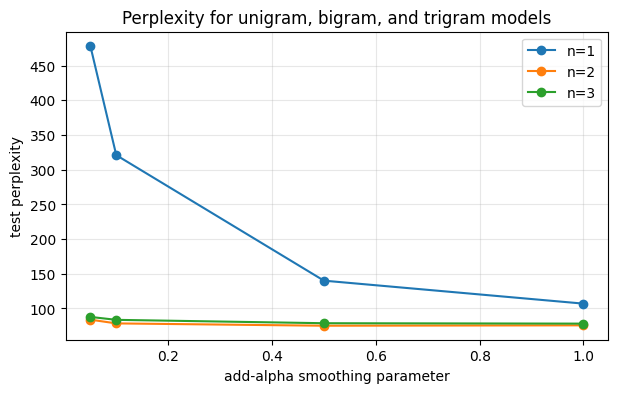

In [13]:
finite = perplexity_table.replace([np.inf, -np.inf], np.nan).dropna(subset=["perplexity"])

plt.figure(figsize=(7, 4))
for n, group in finite.groupby("n"):
    plt.plot(group["alpha"], group["perplexity"], marker="o", label=f"n={n}")
plt.xlabel("add-alpha smoothing parameter")
plt.ylabel("test perplexity")
plt.title("Perplexity for unigram, bigram, and trigram models")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 11. Top next-token predictions

A language model can be used to rank the most likely next tokens for a context.

In [14]:
def top_next_tokens(model, context, alpha=0.1, k=8):
    context = tuple(context)
    rows = []
    for word in model.vocab:
        rows.append({
            "context": " ".join(context) if context else "<empty>",
            "next_token": word,
            "probability": smoothed_probability(model, context, word, alpha=alpha),
            "count": model.next_counts[context][word],
        })
    return pd.DataFrame(rows).sort_values(["probability", "next_token"], ascending=[False, True]).head(k).reset_index(drop=True)

contexts = [("language",), ("next",), ("probability",), ("models",)]
for ctx in contexts:
    print("\nContext:", ctx)
    display(top_next_tokens(bigram, ctx, alpha=0.1, k=6))


Context: ('language',)


,context,next_token,probability,count
0,language,models,0.398437,5
1,language,</s>,0.007812,0
2,language,<unk>,0.007812,0
3,language,a,0.007812,0
4,language,also,0.007812,0
5,language,and,0.007812,0



Context: ('next',)


,context,next_token,probability,count
0,next,token,0.287037,3
1,next,</s>,0.009259,0
2,next,<unk>,0.009259,0
3,next,a,0.009259,0
4,next,also,0.009259,0
5,next,and,0.009259,0



Context: ('probability',)


,context,next_token,probability,count
0,probability,distribution,0.101852,1
1,probability,helps,0.101852,1
2,probability,to,0.101852,1
3,probability,</s>,0.009259,0
4,probability,<unk>,0.009259,0
5,probability,a,0.009259,0



Context: ('models',)


,context,next_token,probability,count
0,models,</s>,0.132911,2
1,models,assign,0.132911,2
2,models,also,0.069620,1
3,models,estimate,0.069620,1
4,models,represent,0.069620,1
5,models,use,0.069620,1


For a trigram model, the context consists of two tokens.

In [15]:
for ctx in [("the", "next"), ("language", "models"), ("a", "probability")]:
    print("\nTrigram context:", ctx)
    display(top_next_tokens(trigram, ctx, alpha=0.1, k=6))


Trigram context: ('the', 'next')


,context,next_token,probability,count
0,the next,token,0.214286,2
1,the next,</s>,0.010204,0
2,the next,<unk>,0.010204,0
3,the next,a,0.010204,0
4,the next,also,0.010204,0
5,the next,and,0.010204,0



Trigram context: ('language', 'models')


,context,next_token,probability,count
0,language models,</s>,0.164062,2
1,language models,also,0.085938,1
2,language models,assign,0.085938,1
3,language models,represent,0.085938,1
4,language models,<unk>,0.007812,0
5,language models,a,0.007812,0



Trigram context: ('a', 'probability')


,context,next_token,probability,count
0,a probability,distribution,0.125000,1
1,a probability,</s>,0.011364,0
2,a probability,<unk>,0.011364,0
3,a probability,a,0.011364,0
4,a probability,also,0.011364,0
5,a probability,and,0.011364,0


## 12. Sampling from an $n$-gram model

A fitted language model is generative. Starting from the start context, repeatedly sample a next token from

$$
p(\cdot \mid h_t).
$$

Then update the context and continue until the end token `</s>` appears.

In [16]:
def next_distribution(model, context, alpha=0.1):
    probs = np.array([smoothed_probability(model, context, word, alpha=alpha) for word in model.vocab], dtype=float)
    probs = probs / probs.sum()
    return model.vocab, probs


def generate_sentence(model, alpha=0.1, max_steps=20, seed=0):
    local_rng = np.random.default_rng(seed)
    n = model.n
    context = tuple([START] * (n - 1))
    generated = []

    for _ in range(max_steps):
        vocab, probs = next_distribution(model, context, alpha=alpha)
        word = local_rng.choice(vocab, p=probs)
        if word == END:
            break
        generated.append("<?>" if word == UNK else word)
        if n > 1:
            context = tuple((list(context) + [word])[-(n - 1):])

    return " ".join(generated)

for n, model in [(1, fit_ngram_model(train_corpus, n=1)), (2, bigram), (3, trigram)]:
    print(f"\nGenerated samples from n={n} model:")
    for seed in range(5):
        print("-", generate_sentence(model, alpha=0.2, seed=seed))


Generated samples from n=1 model:
- only corpus
- maximum uncertainty also uncertainty embeddings into the in models
- context documents the
- 
- uncertainty maximum use

Generated samples from n=2 model:
- prediction distribution
- measures unseen bigram unseen events in statistical labels observed a short maximum generation short entropy maps bigram labels counts documents
- embeddings finite statistical assumption nonzero represent distribution
- also embeddings smoothing next attention likelihood language counts provides augmented generation maps likelihood next token unseen events perplexity probabilities for
- trigram models vectors <?> only from the distribution token models two maximum likelihood short vocabulary in vectors uncertainty bigram observed

Generated samples from n=3 model:
- prediction estimate also <?> symbols two only retrieval neural uncertainty symbols
- measures use bigram unseen finite labels text into measures a sequences models for smoothing events likelih

Generated text from count-based models often contains plausible local fragments but weak global coherence. This is not just a programming issue. It follows from the short-context Markov assumption.

**Try it yourself.** Change `alpha` to `0.01`, `0.5`, or `1.0`. What happens to the generated sentences?

## 13. Bigram model as a transition matrix

A bigram model is a finite Markov chain on tokens. If the vocabulary has size $d$, the transition matrix $P$ has entries

$$
P_{ij}=p(v_j \mid v_i).
$$

Each row sums to one:

$$
\sum_{j=1}^d P_{ij}=1.
$$

Such a matrix is called row-stochastic.

In [17]:
def transition_matrix(model, alpha=0.1):
    assert model.n == 2, "Transition matrix here is for bigram models."
    V = model.vocab
    P = np.zeros((len(V), len(V)))
    for i, u in enumerate(V):
        context = (u,)
        for j, v in enumerate(V):
            P[i, j] = smoothed_probability(model, context, v, alpha=alpha)
        P[i, :] = P[i, :] / P[i, :].sum()
    return V, P

V, P = transition_matrix(bigram, alpha=0.1)
row_sums = P.sum(axis=1)
print("Minimum row sum:", row_sums.min())
print("Maximum row sum:", row_sums.max())

selected_tokens = [tok for tok in ["language", "models", "probability", "token", "context", "next", "uncertainty", END] if tok in V]
idx = [V.index(tok) for tok in selected_tokens]

pd.DataFrame(P[np.ix_(idx, idx)], index=selected_tokens, columns=selected_tokens).round(3)

Minimum row sum: 0.9999999999999998
Maximum row sum: 1.0000000000000002


,language,models,probability,token,context,next,uncertainty,</s>
language,0.008,0.398,0.008,0.008,0.008,0.008,0.008,0.008
models,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.133
probability,0.009,0.009,0.009,0.009,0.009,0.009,0.009,0.009
token,0.008,0.008,0.008,0.008,0.008,0.008,0.008,0.164
context,0.009,0.009,0.009,0.009,0.009,0.009,0.009,0.287
next,0.009,0.009,0.009,0.287,0.009,0.009,0.009,0.009
uncertainty,0.009,0.009,0.009,0.009,0.009,0.009,0.009,0.102
</s>,0.013,0.013,0.013,0.013,0.013,0.013,0.013,0.013


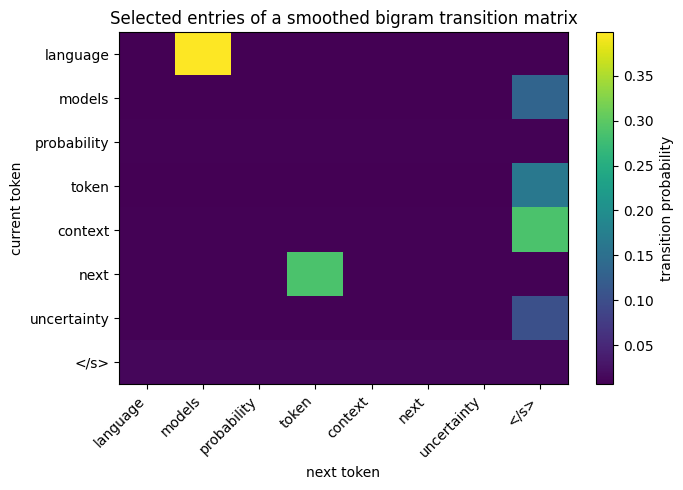

In [18]:
plt.figure(figsize=(7, 5))
plt.imshow(P[np.ix_(idx, idx)], aspect="auto")
plt.xticks(range(len(selected_tokens)), selected_tokens, rotation=45, ha="right")
plt.yticks(range(len(selected_tokens)), selected_tokens)
plt.colorbar(label="transition probability")
plt.title("Selected entries of a smoothed bigram transition matrix")
plt.xlabel("next token")
plt.ylabel("current token")
plt.tight_layout()
plt.show()

## 14. Context entropy

For a fixed context $h$, the entropy of the next-token distribution is

$$
H(W \mid h)=-\sum_{v \in V} p(v \mid h)\log p(v \mid h).
$$

Low entropy means the next token is relatively predictable. High entropy means the model is uncertain.

In [19]:
def context_entropy(model, context, alpha=0.1):
    probs = np.array([smoothed_probability(model, context, word, alpha=alpha) for word in model.vocab])
    probs = probs / probs.sum()
    return float(-np.sum(probs * np.log(probs)))

entropy_rows = []
for context, count in bigram.context_counts.items():
    if context != (START,):
        entropy_rows.append({
            "context": " ".join(context),
            "context_count": count,
            "entropy_nats": context_entropy(bigram, context, alpha=0.1),
            "effective_choices": math.exp(context_entropy(bigram, context, alpha=0.1)),
        })

entropy_table = pd.DataFrame(entropy_rows).sort_values(["entropy_nats", "context"], ascending=[False, True]).reset_index(drop=True)
entropy_table.head(15)

,context,context_count,entropy_nats,effective_choices
0,transformers,1,4.1776,65.209157
1,also,1,4.1776,65.209157
2,assumption,1,4.1776,65.209157
3,attention,1,4.1776,65.209157
4,augmented,1,4.1776,65.209157
5,average,1,4.1776,65.209157
6,bigram,1,4.1776,65.209157
7,classification,1,4.1776,65.209157
8,combines,1,4.1776,65.209157
9,corpus,1,4.1776,65.209157


In a tiny corpus, entropy estimates can be strongly affected by smoothing. In a larger corpus, context entropy is useful for identifying contexts where prediction is easy or difficult.

## 15. Interpolation: combining unigram and bigram models

Add-$\alpha$ smoothing is simple, but another common idea is interpolation. A bigram-unigram interpolation uses

$$
p_\lambda(w_t \mid w_{t-1})
= \lambda p_2(w_t \mid w_{t-1}) + (1-\lambda)p_1(w_t),
$$

where

$$
0 \leq \lambda \leq 1.
$$

This is a convex combination of two probability models. The unigram model is stable but ignores order. The bigram model uses local order but can be sparse.

In [20]:
unigram = fit_ngram_model(train_corpus, n=1, min_count=1)


def interpolated_probability(unigram_model, bigram_model, context, word, lam=0.7, alpha=0.1):
    word = word if word in bigram_model.vocab else UNK
    p_uni = smoothed_probability(unigram_model, tuple(), word, alpha=alpha)
    p_bi = smoothed_probability(bigram_model, context, word, alpha=alpha)
    return lam * p_bi + (1 - lam) * p_uni


def evaluate_interpolated(corpus, unigram_model, bigram_model, lam=0.7, alpha=0.1):
    total_logp = 0.0
    total_tokens = 0
    for sentence in corpus:
        n = 2
        tokens = map_unknown(tokenize(sentence), bigram_model.known_words)
        tokens = add_boundaries(tokens, n)
        for i in range(n - 1, len(tokens)):
            context = tuple(tokens[i - 1:i])
            word = tokens[i]
            prob = interpolated_probability(unigram_model, bigram_model, context, word, lam=lam, alpha=alpha)
            total_logp += math.log(prob)
            total_tokens += 1
    avg_nll = -total_logp / total_tokens
    return avg_nll, math.exp(avg_nll)

interp_rows = []
for lam in np.linspace(0, 1, 11):
    avg_nll, ppl = evaluate_interpolated(test_corpus, unigram, bigram, lam=lam, alpha=0.1)
    interp_rows.append({"lambda_bigram": lam, "avg_nll": avg_nll, "perplexity": ppl})

interp_table = pd.DataFrame(interp_rows)
interp_table

,lambda_bigram,avg_nll,perplexity
0,0.0,5.771274,320.946214
1,0.1,5.251925,190.933485
2,0.2,4.984300,146.101305
3,0.3,4.805095,122.131118
4,0.4,4.673044,107.023035
5,0.5,4.571358,96.675337
6,0.6,4.491874,89.288615
7,0.7,4.430561,83.978523
8,0.8,4.386161,80.331421
9,0.9,4.360590,78.303349


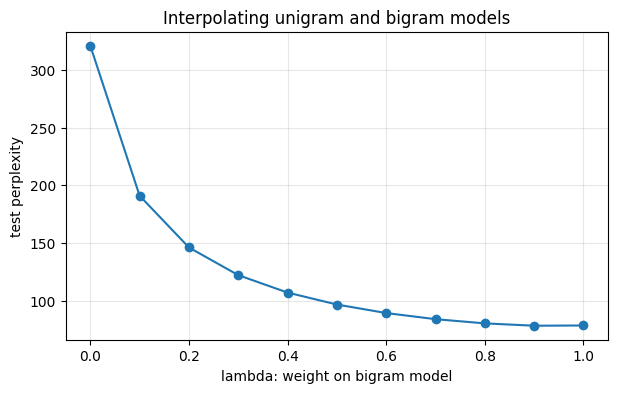

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(interp_table["lambda_bigram"], interp_table["perplexity"], marker="o")
plt.xlabel("lambda: weight on bigram model")
plt.ylabel("test perplexity")
plt.title("Interpolating unigram and bigram models")
plt.grid(True, alpha=0.3)
plt.show()

## 16. Summary of the computational pipeline

The full count-based language modeling pipeline is:

1. choose a tokenizer;
2. choose boundary tokens and unknown-token handling;
3. choose an order $n$;
4. count contexts $C(h)$ and context-token pairs $C(h,v)$;
5. estimate probabilities by MLE or smoothing;
6. compute log-probability and perplexity;
7. generate text by sequential sampling;
8. inspect model behavior using tables, entropy, and transition matrices.

The simplicity of $n$-gram models is valuable: every probability can be traced back to a count.

## Exercises

### Conceptual exercises

1. Explain why the exact chain rule is not enough to build a practical language model directly.
2. What is the Markov approximation in a bigram model?
3. Why do we need start and end tokens?
4. What is the zero-probability problem?
5. Explain add-$\alpha$ smoothing as shrinkage toward the uniform distribution.
6. Why can a trigram model have higher variance than a bigram model?
7. What does perplexity measure?
8. Why is a bigram model a Markov chain?

### Mathematical exercises

1. Suppose $C(h,a)=3$, $C(h,b)=1$, and $C(h,c)=0$. Compute the MLE probabilities.
2. For the same counts and vocabulary size $|V|=3$, compute add-one smoothed probabilities.
3. For the same counts and $\alpha=0.5$, compute the smoothed probabilities.
4. Prove that add-$\alpha$ probabilities sum to one.
5. If a model assigns probabilities $0.5$, $0.25$, $0.1$, and $0.4$ to four correct next tokens, compute average negative log-likelihood and perplexity.
6. Show that a smoothed bigram transition matrix is row-stochastic.
7. Explain why $\pi_{t+1}=\pi_t P$ is again a probability distribution when $P$ is row-stochastic.

### Python exercises

1. Change `min_count` to `2`. Which words become `<unk>`?
2. Build a trigram model and inspect predictions for five contexts.
3. Generate ten sentences from unigram, bigram, and trigram models. Compare their coherence.
4. Try `alpha=0.01`, `0.1`, `0.5`, and `1.0`. How does smoothing affect perplexity?
5. Write a function that returns the contexts with the lowest entropy.
6. Create your own small corpus of at least 15 sentences and repeat the full analysis.
7. Implement interpolation among unigram, bigram, and trigram probabilities.

## Mini-project: a small-domain language model

Choose a small domain such as:

- course descriptions;
- textbook section titles;
- research abstracts;
- advising questions;
- AI and machine learning news headlines.

Build unigram, bigram, and trigram language models.

Your report should include:

1. your tokenization rule;
2. vocabulary size and unknown-token rule;
3. number of observed contexts for each $n$;
4. top next-token predictions for at least five contexts;
5. generated text samples;
6. test perplexity for several values of $\alpha$;
7. a discussion of where the Markov assumption works and where it fails;
8. one transition-matrix or entropy visualization.

A strong report should connect each computational result back to a mathematical object: counts, conditional probability rows, smoothing, entropy, or perplexity.

## AI-assisted study prompts

Use an AI system only as a study assistant. Do not copy answers without checking the mathematics.

### Prompt 1: audit the Markov assumption

```text
I am studying n-gram language models. Explain the Markov assumption in a bigram model. Give one example where it works and one example where it fails because of long-range dependence.
```

### Prompt 2: verify the MLE derivation

```text
Derive the maximum likelihood estimator for p(v | h) in an n-gram model using counts C(h,v). Explain why the estimator is undefined when C(h)=0.
```

### Prompt 3: critique smoothing

```text
Explain add-alpha smoothing as shrinkage toward a uniform distribution. What problem does it solve, and what problem can it introduce when the vocabulary is large?
```

After receiving an AI response, check whether it correctly distinguishes an exact chain-rule identity from the approximate $n$-gram assumption.